# Train and track machine learning models with MLflow in Microsoft Fabric

In [29]:
# Azure storage access info for open dataset diabetes
blob_account_name = "azureopendatastorage"
blob_container_name = "mlsamples"
blob_relative_path = "diabetes"
blob_sas_token = r"" # Blank since container is Anonymous access
    
# Set Spark config to access  blob storage
wasbs_path = f"wasbs://%s@%s.blob.core.windows.net/%s" % (blob_container_name, blob_account_name, blob_relative_path)
spark.conf.set("fs.azure.sas.%s.%s.blob.core.windows.net" % (blob_container_name, blob_account_name), blob_sas_token)
print("Remote blob path: " + wasbs_path)
    
# Spark read parquet, note that it won't load any data yet by now
df = spark.read.parquet(wasbs_path)
df.head(5)

StatementMeta(, b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3, 33, Finished, Available, Finished, False)

Remote blob path: wasbs://mlsamples@azureopendatastorage.blob.core.windows.net/diabetes


[Row(AGE=59, SEX=2, BMI=32.1, BP=101.0, S1=157, S2=93.2, S3=38.0, S4=4.0, S5=4.8598, S6=87, Y=151),
 Row(AGE=48, SEX=1, BMI=21.6, BP=87.0, S1=183, S2=103.2, S3=70.0, S4=3.0, S5=3.8918, S6=69, Y=75),
 Row(AGE=72, SEX=2, BMI=30.5, BP=93.0, S1=156, S2=93.6, S3=41.0, S4=4.0, S5=4.6728, S6=85, Y=141),
 Row(AGE=24, SEX=1, BMI=25.3, BP=84.0, S1=198, S2=131.4, S3=40.0, S4=5.0, S5=4.8903, S6=89, Y=206),
 Row(AGE=50, SEX=1, BMI=23.0, BP=101.0, S1=192, S2=125.4, S3=52.0, S4=4.0, S5=4.2905, S6=80, Y=135)]

In [30]:
display(df)

StatementMeta(, b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3, 34, Finished, Available, Finished, False)

SynapseWidget(Synapse.DataFrame, 2b9b320c-4061-489e-a057-9661c6033c5b)

In [31]:
import pandas as pd
import numpy as np

df = df.toPandas()
df.head()

StatementMeta(, b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3, 35, Finished, Available, Finished, False)

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.0,157,93.2,38.0,4.0,4.8598,87,151
1,48,1,21.6,87.0,183,103.2,70.0,3.0,3.8918,69,75
2,72,2,30.5,93.0,156,93.6,41.0,4.0,4.6728,85,141
3,24,1,25.3,84.0,198,131.4,40.0,5.0,4.8903,89,206
4,50,1,23.0,101.0,192,125.4,52.0,4.0,4.2905,80,135


In [32]:
# Train a machine learning model
from sklearn.model_selection import train_test_split

X, y = df[['AGE','SEX','BMI','BP','S1','S2','S3','S4','S5','S6']].values, df['Y'].values

X_train, X_test, y_train ,y_test = train_test_split(X, y, test_size=0.30, random_state=0)


StatementMeta(, b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3, 36, Finished, Available, Finished, False)

In [33]:
print(X_train.shape[0])
print(X_test.shape[0])
print(y_train.shape[0])
print(y_test.shape[0])

StatementMeta(, b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3, 37, Finished, Available, Finished, False)

309
133
309
133


In [34]:
# this code creates MLFlow experiment named experiment-diabetes. This models will be tracked in this experiment. 

import mlflow
experiment_name = "experiment_diabetes"
mlflow.set_experiment(experiment_name)

StatementMeta(, b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3, 38, Finished, Available, Finished, False)

<Experiment: artifact_location='sds://onelakesoutheastasia.pbidedicated.windows.net/f5ab2e1e-ed63-4543-8ba2-419886c6e8d4/0dd07d1a-c055-478c-959b-d324d3e3c642', creation_time=1774340702675, experiment_id='0dd07d1a-c055-478c-959b-d324d3e3c642', last_update_time=1774340702675, lifecycle_stage='active', name='experiment_diabetes', tags={}>

In [35]:
# The code trains a regression model using Linear Regression. 
# Parameters, metrics and artifacts are automatically logged with MLFlow.
# Additionally, a parameter called 'estimator' with the value 'LinearRegression'


from sklearn.linear_model import LinearRegression

with mlflow.start_run():
    mlflow.autolog()

    model = LinearRegression()
    model.fit(X_train, y_train)

    mlflow.log_param("estimator", "LinearRegression")

StatementMeta(, b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3, 39, Finished, Available, Finished, False)

2026/03/24 08:52:36 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


In [36]:
# The code trains a regression model using DecisionTreeRegressor. 
# Parameters, metrics and artifacts are automatically logged with MLFlow.
# Additionally, a parameter called 'estimator' with the value 'DecisionTreeRegressor'


from sklearn.tree import DecisionTreeRegressor
    
with mlflow.start_run():
   mlflow.autolog()
    
   model = DecisionTreeRegressor(max_depth=5) 
   model.fit(X_train, y_train)
    
   mlflow.log_param("estimator", "DecisionTreeRegressor")

StatementMeta(, b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3, 40, Finished, Available, Finished, False)

2026/03/24 08:52:43 INFO mlflow.tracking.fluent: Autologging successfully enabled for sklearn.


#### Use MLFlow to search and view your experiments

In [37]:
# To list all experiments, use the following code:

import mlflow
experiments = mlflow.search_experiments()
for exp in experiments:
    print(exp.name)


StatementMeta(, b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3, 41, Finished, Available, Finished, False)

experiment_diabetes


In [38]:
# To retrieve a specific experiment, you can get it by its name:

experiment_name = "experiment_diabetes"
exp = mlflow.get_experiment_by_name(experiment_name)
print(exp)

StatementMeta(, b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3, 42, Finished, Available, Finished, False)

<Experiment: artifact_location='sds://onelakesoutheastasia.pbidedicated.windows.net/f5ab2e1e-ed63-4543-8ba2-419886c6e8d4/0dd07d1a-c055-478c-959b-d324d3e3c642', creation_time=1774340702675, experiment_id='0dd07d1a-c055-478c-959b-d324d3e3c642', last_update_time=1774340702675, lifecycle_stage='active', name='experiment_diabetes', tags={}>


In [39]:
# Using an experiment name, you can retrieve all jobs of that experiment:
mlflow.search_runs(exp.experiment_id)

StatementMeta(, b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3, 43, Finished, Available, Finished, False)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.training_score,metrics.training_mean_absolute_error,metrics.training_r2_score,metrics.training_mean_squared_error,...,tags.estimator_class,tags.synapseml.run.artifactJobId,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.runName,tags.estimator_name,tags.synapseml.livy.id,tags.synapseml.user.name,tags.mlflow.source.type,tags.synapseml.user.id
0,cdccb2d1-98a6-4387-9285-6d6cc68372eb,0dd07d1a-c055-478c-959b-d324d3e3c642,FINISHED,sds://onelakesoutheastasia.pbidedicated.window...,2026-03-24 08:52:42.590000+00:00,2026-03-24 08:52:47.247000+00:00,0.732149,31.483440,0.732149,1683.830915,...,sklearn.tree._classes.DecisionTreeRegressor,d938f31a-c733-4b11-bab1-7bb71f01eebc,/home/trusted-service-user/cluster-env/trident...,trusted-service-user,mango_horse_3cptn8t2,DecisionTreeRegressor,b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3,Sonali Bandu Patil,LOCAL,239a9272-a646-4451-a314-d6d66e7514fb
1,dc85a87e-798f-4db0-a3c6-2a7f57d85201,0dd07d1a-c055-478c-959b-d324d3e3c642,FINISHED,sds://onelakesoutheastasia.pbidedicated.window...,2026-03-24 08:52:35.923000+00:00,2026-03-24 08:52:41.031000+00:00,0.553938,43.054973,0.553938,2804.143561,...,sklearn.linear_model._base.LinearRegression,8f670947-0f50-4587-b7eb-5db0ec23241b,/home/trusted-service-user/cluster-env/trident...,trusted-service-user,gifted_eye_rhhcj28d,LinearRegression,b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3,Sonali Bandu Patil,LOCAL,239a9272-a646-4451-a314-d6d66e7514fb
2,b4cf8cd1-f92c-40c8-91d1-850ac9ce4ac7,0dd07d1a-c055-478c-959b-d324d3e3c642,FINISHED,sds://onelakesoutheastasia.pbidedicated.window...,2026-03-24 08:32:40.736000+00:00,2026-03-24 08:32:45.171000+00:00,0.732149,31.483440,0.732149,1683.830915,...,sklearn.tree._classes.DecisionTreeRegressor,a8f33a91-24fc-4dec-8e8e-798c7530ec86,/home/trusted-service-user/cluster-env/trident...,trusted-service-user,tidy_ticket_xtql3nbq,DecisionTreeRegressor,b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3,Sonali Bandu Patil,LOCAL,239a9272-a646-4451-a314-d6d66e7514fb
3,0a28474d-13db-4402-8aca-b260e9092ddf,0dd07d1a-c055-478c-959b-d324d3e3c642,FINISHED,sds://onelakesoutheastasia.pbidedicated.window...,2026-03-24 08:31:56.178000+00:00,2026-03-24 08:32:01.176000+00:00,0.732149,31.483440,0.732149,1683.830915,...,sklearn.tree._classes.DecisionTreeRegressor,6d4d97c0-0efb-4e61-a87b-28e7b4fd42fb,/home/trusted-service-user/cluster-env/trident...,trusted-service-user,loyal_book_hjvll56m,DecisionTreeRegressor,b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3,Sonali Bandu Patil,LOCAL,239a9272-a646-4451-a314-d6d66e7514fb
4,a27a2f24-9d3e-4274-8257-ebc5d9ebae15,0dd07d1a-c055-478c-959b-d324d3e3c642,FAILED,sds://onelakesoutheastasia.pbidedicated.window...,2026-03-24 08:31:26.638000+00:00,2026-03-24 08:31:26.859000+00:00,NaN,NaN,NaN,NaN,...,None,5fd5a2d0-6c00-4434-976c-a32f8405e3eb,/home/trusted-service-user/cluster-env/trident...,trusted-service-user,gentle_town_cm0y8wqp,None,b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3,Sonali Bandu Patil,LOCAL,239a9272-a646-4451-a314-d6d66e7514fb
5,a7d1d774-a7d3-4307-86a2-9f69e3b39150,0dd07d1a-c055-478c-959b-d324d3e3c642,FINISHED,sds://onelakesoutheastasia.pbidedicated.window...,2026-03-24 08:31:20.463000+00:00,2026-03-24 08:31:24.935000+00:00,0.553938,43.054973,0.553938,2804.143561,...,sklearn.linear_model._base.LinearRegression,312f95e1-192d-4feb-99b8-08eec7c76f76,/home/trusted-service-user/cluster-env/trident...,trusted-service-user,placid_tail_66vcr7gt,LinearRegression,b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3,Sonali Bandu Patil,LOCAL,239a9272-a646-4451-a314-d6d66e7514fb
6,cfe08ca7-328e-47c5-a5c0-62d5d10f0dad,0dd07d1a-c055-478c-959b-d324d3e3c642,FAILED,sds://onelakesoutheastasia.pbidedicated.window...,2026-03-24 08:30:20.472000+00:00,2026-03-24 08:30:20.827000+00:00,NaN,NaN,NaN,NaN,...,None,0a249ada-358d-42f2-9313-2c1fcdba2d26,/home/trusted-service-user/cluster-env/trident...,trusted-service-user,nice_cow_tg7zn0c6,None,b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3,Sonali Bandu Patil,LOCAL,239a9272-a646-4451-a314-d

In [40]:
# To more easily compare job runs and outputs, you can configure the search to order the results. 
# For example, the following cell orders the results by start_time, and only shows a maximum of 2 results:

mlflow.search_runs(exp.experiment_id, order_by=["start_time DESC"], max_results=2)

StatementMeta(, b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3, 44, Finished, Available, Finished, False)

,run_id,experiment_id,status,artifact_uri,start_time,end_time,metrics.training_score,metrics.training_mean_absolute_error,metrics.training_r2_score,metrics.training_mean_squared_error,...,tags.estimator_class,tags.synapseml.run.artifactJobId,tags.mlflow.source.name,tags.mlflow.user,tags.mlflow.runName,tags.estimator_name,tags.synapseml.livy.id,tags.synapseml.user.name,tags.mlflow.source.type,tags.synapseml.user.id
0,cdccb2d1-98a6-4387-9285-6d6cc68372eb,0dd07d1a-c055-478c-959b-d324d3e3c642,FINISHED,sds://onelakesoutheastasia.pbidedicated.window...,2026-03-24 08:52:42.590000+00:00,2026-03-24 08:52:47.247000+00:00,0.732149,31.483440,0.732149,1683.830915,...,sklearn.tree._classes.DecisionTreeRegressor,d938f31a-c733-4b11-bab1-7bb71f01eebc,/home/trusted-service-user/cluster-env/trident...,trusted-service-user,mango_horse_3cptn8t2,DecisionTreeRegressor,b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3,Sonali Bandu Patil,LOCAL,239a9272-a646-4451-a314-d6d66e7514fb
1,dc85a87e-798f-4db0-a3c6-2a7f57d85201,0dd07d1a-c055-478c-959b-d324d3e3c642,FINISHED,sds://onelakesoutheastasia.pbidedicated.window...,2026-03-24 08:52:35.923000+00:00,2026-03-24 08:52:41.031000+00:00,0.553938,43.054973,0.553938,2804.143561,...,sklearn.linear_model._base.LinearRegression,8f670947-0f50-4587-b7eb-5db0ec23241b,/home/trusted-service-user/cluster-env/trident...,trusted-service-user,gifted_eye_rhhcj28d,LinearRegression,b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3,Sonali Bandu Patil,LOCAL,239a9272-a646-4451-a314-d6d66e7514fb


StatementMeta(, b16b4ef1-410a-437f-a7a4-e4ae5a5d95f3, 45, Finished, Available, Finished, False)

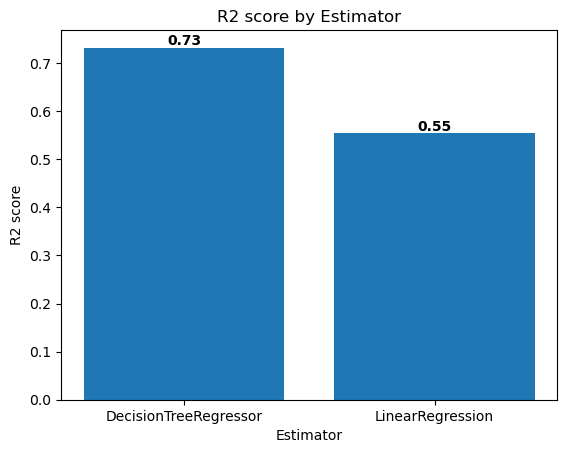

In [41]:
# Finally, you can plot the evaluation metrics of multiple models next to each other to easily compare models:

import matplotlib.pyplot as plt
   
df_results = mlflow.search_runs(exp.experiment_id, order_by=["start_time DESC"], max_results=2)[["metrics.training_r2_score", "params.estimator"]]
   
fig, ax = plt.subplots()
ax.bar(df_results["params.estimator"], df_results["metrics.training_r2_score"])
ax.set_xlabel("Estimator")
ax.set_ylabel("R2 score")
ax.set_title("R2 score by Estimator")
for i, v in enumerate(df_results["metrics.training_r2_score"]):
    ax.text(i, v, str(round(v, 2)), ha='center', va='bottom', fontweight='bold')
plt.show()